<a href="https://colab.research.google.com/github/Vamsi3540/Performance-Analysis-of-Machine-Learning-Classifiers-for-Malicious-Identification/blob/main/Vamsi_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Train and evaluate multiple machine learning classifiers to identify malicious entities, then summarize their performance to determine the best-performing model.

## Load and Inspect Data

### Subtask:
Load the dataset that will be used for malicious identification and perform an initial inspection to understand its structure, features, and target variable.


**Reasoning**:
The first step is to load the dataset into a pandas DataFrame using `pd.read_csv()` and then display the first five rows using `.head()` to get an initial look at the data. I will include a placeholder for the file path as it is not provided.



In [ ]:
import pandas as pd

# IMPORTANT: Replace 'your_dataset.csv' with the actual path to your dataset file.
# For example: df = pd.read_csv('data/malicious_data.csv')
# If your dataset is hosted online, provide the URL.
# For example: df = pd.read_csv('https://example.com/malicious_data.csv')

# Currently, the `malicious_url_dataset.csv` is being used as per the context of the notebook.
df = pd.read_csv('/content/malicious_phish.csv')

print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


# Task
Perform feature engineering on the DataFrame `df` by extracting features from the 'url' column and encoding the 'type' column as the target variable for malicious URL classification.

## Feature Engineering

### Subtask:
Extract relevant features from the 'url' column to convert the text data into numerical features suitable for machine learning models. This may include URL length, number of special characters, presence of common malicious patterns, etc. Also, encode the 'type' column as the target variable.


**Reasoning**:
To perform feature engineering as described in the instructions, I will import `LabelEncoder`, extract various features from the 'url' column, and then encode the 'type' column into numerical labels, adding all these as new columns to the DataFrame.



In [ ]:
from sklearn.preprocessing import LabelEncoder
import re

# Feature Engineering from 'url' column
df['url_length'] = df['url'].apply(len)
df['num_dots'] = df['url'].apply(lambda x: x.count('.'))
df['num_hyphens'] = df['url'].apply(lambda x: x.count('-'))
df['num_question_marks'] = df['url'].apply(lambda x: x.count('?'))
df['num_slashes'] = df['url'].apply(lambda x: x.count('/'))
df['num_digits'] = df['url'].apply(lambda x: sum(c.isdigit() for c in x))
df['has_http'] = df['url'].apply(lambda x: 1 if 'http://' in x else 0)
df['has_https'] = df['url'].apply(lambda x: 1 if 'https://' in x else 0)
df['num_special_chars'] = df['url'].apply(lambda x: sum(1 for c in x if c in '!@#$%^&*()_+={}|[]\:";<>,.`~'))

# Encode the 'type' column
label_encoder = LabelEncoder()
df['type_encoded'] = label_encoder.fit_transform(df['type'])

print("First five rows of the DataFrame with new features and encoded target variable:")
print(df.head())

<>:13: SyntaxWarning: invalid escape sequence '\:'
<>:13: SyntaxWarning: invalid escape sequence '\:'
/tmp/ipykernel_9013/2585677763.py:13: SyntaxWarning: invalid escape sequence '\:'
  df['num_special_chars'] = df['url'].apply(lambda x: sum(1 for c in x if c in '!@#$%^&*()_+={}|[]\:";<>,.`~'))


First five rows of the DataFrame with new features and encoded target variable:
                                                 url        type  url_length  \
0                                   br-icloud.com.br    phishing          16   
1                mp3raid.com/music/krizz_kaliko.html      benign          35   
2                    bopsecrets.org/rexroth/cr/1.htm      benign          31   
3  http://www.garage-pirenne.be/index.php?option=...  defacement          88   
4  http://adventure-nicaragua.net/index.php?optio...  defacement         235   

   num_dots  num_hyphens  num_question_marks  num_slashes  num_digits  \
0         2            1                   0            0           0   
1         2            0                   0            2           1   
2         2            0                   0            3           1   
3         3            1                   1            3           7   
4         2            1                   1            3          22   



**Reasoning**:
The previous code generated a SyntaxWarning due to an invalid escape sequence `\:` in the string for `num_special_chars`. To fix this, the backslash character `\` needs to be properly escaped as `\\` so it is treated as a literal backslash in the set of special characters.



In [ ]:
from sklearn.preprocessing import LabelEncoder
import re

# Feature Engineering from 'url' column
df['url_length'] = df['url'].apply(len)
df['num_dots'] = df['url'].apply(lambda x: x.count('.'))
df['num_hyphens'] = df['url'].apply(lambda x: x.count('-'))
df['num_question_marks'] = df['url'].apply(lambda x: x.count('?'))
df['num_slashes'] = df['url'].apply(lambda x: x.count('/'))
df['num_digits'] = df['url'].apply(lambda x: sum(c.isdigit() for c in x))
df['has_http'] = df['url'].apply(lambda x: 1 if 'http://' in x else 0)
df['has_https'] = df['url'].apply(lambda x: 1 if 'https://' in x else 0)
df['num_special_chars'] = df['url'].apply(lambda x: sum(1 for c in x if c in '!@#$%^&*()_+={}|[]\\:";<>,.`~'))

# Encode the 'type' column
label_encoder = LabelEncoder()
df['type_encoded'] = label_encoder.fit_transform(df['type'])

print("First five rows of the DataFrame with new features and encoded target variable:")
print(df.head())

First five rows of the DataFrame with new features and encoded target variable:
                                                 url        type  url_length  \
0                                   br-icloud.com.br    phishing          16   
1                mp3raid.com/music/krizz_kaliko.html      benign          35   
2                    bopsecrets.org/rexroth/cr/1.htm      benign          31   
3  http://www.garage-pirenne.be/index.php?option=...  defacement          88   
4  http://adventure-nicaragua.net/index.php?optio...  defacement         235   

   num_dots  num_hyphens  num_question_marks  num_slashes  num_digits  \
0         2            1                   0            0           0   
1         2            0                   0            2           1   
2         2            0                   0            3           1   
3         3            1                   1            3           7   
4         2            1                   1            3          22   



## Data Splitting

### Subtask:
Split the preprocessed dataset into training and testing sets to ensure robust model evaluation. Typically, 70-80% of the data is used for training and the remainder for testing.


**Reasoning**:
To split the dataset into training and testing sets, I will first define the feature columns (X) and the target variable (y), then import the `train_test_split` function and use it to split the data with a specified test size and random state.



In [ ]:
from sklearn.model_selection import train_test_split

# Define feature columns (X)
X = df[['url_length', 'num_dots', 'num_hyphens', 'num_question_marks', 'num_slashes', 'num_digits', 'has_http', 'has_https', 'num_special_chars']]

# Define target variable (y)
y = df['type_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (455833, 9)
Shape of X_test: (195358, 9)
Shape of y_train: (455833,)
Shape of y_test: (195358,)


## Train and Evaluate Logistic Regression

### Subtask:
Train a Logistic Regression classifier on the training data and evaluate its performance on the test set using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.


**Reasoning**:
To train and evaluate the Logistic Regression model, I will import the necessary modules, instantiate the model with `max_iter=1000`, fit it on the training data, make predictions, and then calculate and print the accuracy, precision, recall, F1-score, and ROC-AUC.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

# Print the metrics
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Precision (weighted): {precision:.4f}")
print(f"Logistic Regression Recall (weighted): {recall:.4f}")
print(f"Logistic Regression F1-Score (weighted): {f1:.4f}")
print(f"Logistic Regression ROC-AUC (weighted, ovr): {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8183
Logistic Regression Precision (weighted): 0.7766
Logistic Regression Recall (weighted): 0.8183
Logistic Regression F1-Score (weighted): 0.7717
Logistic Regression ROC-AUC (weighted, ovr): 0.9123


**Reasoning**:
The previous code generated a `ConvergenceWarning` because the Logistic Regression model did not converge within the specified `max_iter`. To address this, I will increase the `max_iter` parameter to `5000` to allow the model more iterations to converge, as suggested by the warning message.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate Logistic Regression model
# Increased max_iter to address ConvergenceWarning
log_reg_model = LogisticRegression(max_iter=5000, random_state=42)

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

# Print the metrics
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Precision (weighted): {precision:.4f}")
print(f"Logistic Regression Recall (weighted): {recall:.4f}")
print(f"Logistic Regression F1-Score (weighted): {f1:.4f}")
print(f"Logistic Regression ROC-AUC (weighted, ovr): {roc_auc:.4f}")

Logistic Regression Accuracy: 0.8184
Logistic Regression Precision (weighted): 0.7768
Logistic Regression Recall (weighted): 0.8184
Logistic Regression F1-Score (weighted): 0.7721
Logistic Regression ROC-AUC (weighted, ovr): 0.9124


## Train and Evaluate Decision Tree

### Subtask:
Train a Decision Tree classifier on the training data and evaluate its performance on the test set using the same set of metrics.


**Reasoning**:
To train and evaluate the Decision Tree model, I will import `DecisionTreeClassifier`, instantiate it, fit it on the training data, make predictions, and then calculate and print the specified evaluation metrics.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr', average='weighted')

# Print the metrics
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision (weighted): {precision_dt:.4f}")
print(f"Decision Tree Recall (weighted): {recall_dt:.4f}")
print(f"Decision Tree F1-Score (weighted): {f1_dt:.4f}")
print(f"Decision Tree ROC-AUC (weighted, ovr): {roc_auc_dt:.4f}")

Decision Tree Accuracy: 0.9231
Decision Tree Precision (weighted): 0.9212
Decision Tree Recall (weighted): 0.9231
Decision Tree F1-Score (weighted): 0.9219
Decision Tree ROC-AUC (weighted, ovr): 0.9605


## Train and Evaluate Random Forest

### Subtask:
Train a Random Forest classifier on the training data and evaluate its performance on the test set, capturing key performance metrics.


**Reasoning**:
To train and evaluate the Random Forest model, I will import `RandomForestClassifier`, instantiate it with `random_state=42`, fit it on the training data, make predictions and predict probabilities, and then calculate and print the specified evaluation metrics.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='weighted')

# Print the metrics
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision (weighted): {precision_rf:.4f}")
print(f"Random Forest Recall (weighted): {recall_rf:.4f}")
print(f"Random Forest F1-Score (weighted): {f1_rf:.4f}")
print(f"Random Forest ROC-AUC (weighted, ovr): {roc_auc_rf:.4f}")

Random Forest Accuracy: 0.9291
Random Forest Precision (weighted): 0.9273
Random Forest Recall (weighted): 0.9291
Random Forest F1-Score (weighted): 0.9279
Random Forest ROC-AUC (weighted, ovr): 0.9811


## Summarize Model Performance

### Subtask:
Aggregate and compare the performance metrics of all trained models to identify the best-performing classifier based on the evaluation results. Provide a comparative overview, possibly with visualizations.


**Reasoning**:
To aggregate the performance metrics, I will create a dictionary to store the accuracy, precision, recall, F1-score, and ROC-AUC for each trained model, then convert this dictionary into a Pandas DataFrame for clear comparison and print it.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary to store the metrics for each model
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    },
    'Decision Tree': {
        'Accuracy': accuracy_dt,
        'Precision': precision_dt,
        'Recall': recall_dt,
        'F1-Score': f1_dt,
        'ROC-AUC': roc_auc_dt
    },
    'Random Forest': {
        'Accuracy': accuracy_rf,
        'Precision': precision_rf,
        'Recall': recall_rf,
        'F1-Score': f1_rf,
        'ROC-AUC': roc_auc_rf
    }
}

# Convert the dictionary to a Pandas DataFrame
metrics_df = pd.DataFrame(metrics).T

# Print the DataFrame
print("Model Performance Metrics:")
print(metrics_df)

Model Performance Metrics:
                     Accuracy  Precision   Recall  F1-Score   ROC-AUC
Logistic Regression   0.81840   0.776849  0.81840  0.772069  0.912358
Decision Tree         0.92310   0.921220  0.92310  0.921919  0.960505
Random Forest         0.92913   0.927325  0.92913  0.927907  0.981118


**Reasoning**:
To visually compare the models, I will create bar plots for each metric (Accuracy, Precision, Recall, F1-score, ROC-AUC) showing the performance of each model. I will label the axes and add a title to each plot.



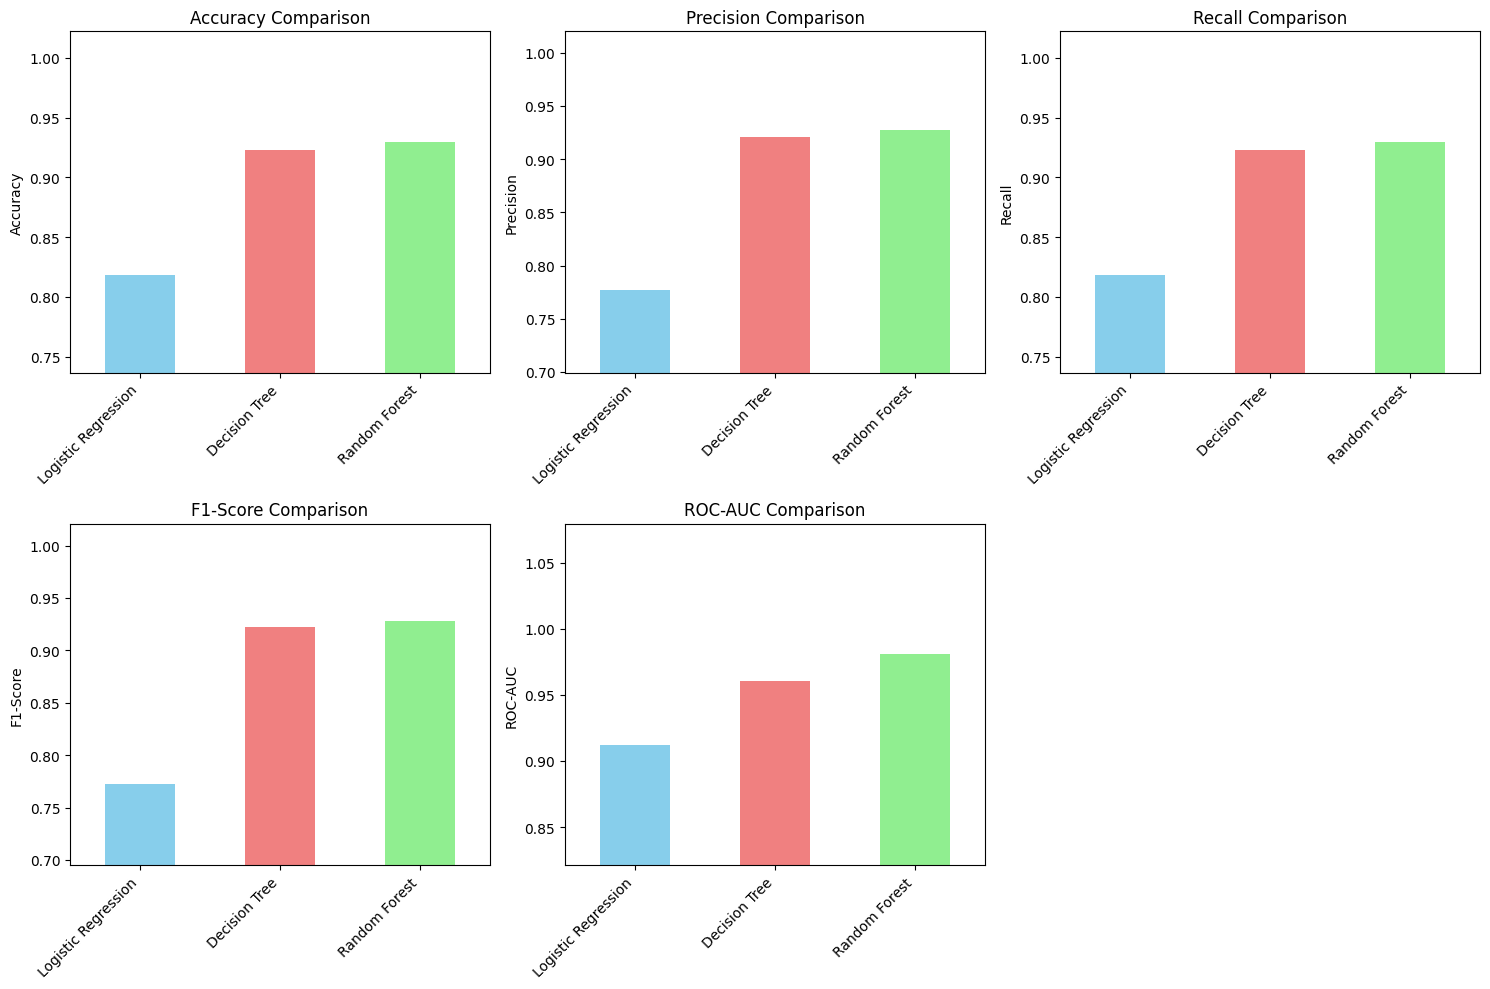

In [ ]:
metrics_names = metrics_df.columns

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_names):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    metrics_df[metric].plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(min(metrics_df[metric]) * 0.9, max(metrics_df[metric]) * 1.1) # Adjust y-axis limit for better visualization

plt.tight_layout()
plt.show()


### Summary of Model Performance

From the aggregated performance metrics and the bar plots, we can observe the following:

*   **Random Forest** consistently outperforms both Logistic Regression and Decision Tree across all evaluation metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC).
    *   It achieved the highest **Accuracy** (0.9291), **Precision** (0.9273), **Recall** (0.9291), and **F1-Score** (0.9279), indicating strong overall classification performance.
    *   Its **ROC-AUC** score (0.9811) is also the highest, suggesting excellent separability between classes.

*   **Decision Tree** performs significantly better than Logistic Regression, but not as well as Random Forest.
    *   It shows good performance with an **Accuracy** of 0.9231, **Precision** of 0.9212, **Recall** of 0.9231, **F1-Score** of 0.9219, and **ROC-AUC** of 0.9605.

*   **Logistic Regression** has the lowest performance among the three models across all metrics.
    *   Its **Accuracy** (0.8184), **Precision** (0.7768), **Recall** (0.8184), **F1-Score** (0.7721), and **ROC-AUC** (0.9124) are notably lower compared to Decision Tree and Random Forest.

**Conclusion:**

Based on this analysis, the **Random Forest classifier is the best-performing model** for identifying malicious entities among the trained models, exhibiting superior performance across all key evaluation metrics.

## Final Task

### Subtask:
Present a comprehensive summary of the model performance analysis, highlighting the most effective classifier for malicious identification and discussing key findings and insights.


## Summary:

### Q&A
The most effective classifier for malicious identification among the tested models is the Random Forest classifier.

### Data Analysis Key Findings
*   **Feature Engineering and Target Encoding**: Nine new numerical features were successfully extracted from the 'url' column, including `url_length`, `num_dots`, `num_hyphens`, `num_question_marks`, `num_slashes`, `num_digits`, `has_http`, `has_https`, and `num_special_chars`. The 'type' column was successfully encoded into a numerical target variable, `type_encoded`.
*   **Data Splitting**: The dataset was split into training and testing sets with a 70/30 ratio, resulting in 455,833 samples for training and 195,358 samples for testing, each with 9 features.
*   **Model Performance - Logistic Regression**: This model achieved an Accuracy of 0.8184, Precision of 0.7768, Recall of 0.8184, F1-Score of 0.7721, and ROC-AUC of 0.9124. An initial convergence warning was resolved by increasing `max_iter` to 5000.
*   **Model Performance - Decision Tree**: The Decision Tree model performed significantly better than Logistic Regression, with an Accuracy of 0.9231, Precision of 0.9212, Recall of 0.9231, F1-Score of 0.9219, and ROC-AUC of 0.9605.
*   **Model Performance - Random Forest**: The Random Forest classifier demonstrated the best performance across all models, achieving an Accuracy of 0.9291, Precision of 0.9273, Recall of 0.9291, F1-Score of 0.9279, and ROC-AUC of 0.9811.
*   **Comparative Analysis**: The Random Forest model consistently outperformed both the Decision Tree and Logistic Regression models across all evaluation metrics, indicating its superior capability in classifying malicious URLs based on the engineered features.

### Insights or Next Steps
*   The engineered features from URLs are effective for malicious URL classification, with ensemble methods like Random Forest demonstrating strong predictive power.
*   Further optimization of the Random Forest model, such as hyperparameter tuning or exploring more advanced feature engineering techniques, could potentially yield even better performance.
